# Where Will New F&B Permits Appear? Business ML on 3 Million Korean Records

This notebook turns the **South Korea Food-Service Permits - Snapshot** into a business forecasting problem:

> **Which local authority × food-service category markets are likely to generate the most new administrative permits over the next 3 months?**

The commercial use case is territory planning for POS/payment providers, food-service suppliers, kitchen-equipment vendors, franchise development teams, and commercial real-estate analysts.

### What this notebook does

1. audits temporal coverage and source freshness;
2. converts 3,010,802 permit rows into a monthly local-market panel;
3. builds leakage-safe lag / rolling / seasonality features;
4. performs quarterly **walk-forward validation**;
5. compares seasonal naive, XGBoost Poisson, squared-error, Tweedie, and a seasonal/ML blend;
6. evaluates business metrics such as **top-10% market capture**;
7. explains the tree model with SHAP when available;
8. attaches empirical conformal-style uncertainty bands to the final holdout predictions.

**Important scope:** this dataset is a **current snapshot**, not 12 monthly snapshots. We forecast the future count of rows by their administrative `permit_date`; we do **not** reconstruct past monthly market states or claim that `permit_date` is the physical opening date.


## 1. Business scenario and leakage rules

**Decision:** prioritize local markets for sales coverage / expansion research.

**Unit:** `authority_code × source_key` (general restaurants, rest cafes, bakeries).

**Target:** cumulative number of new administrative permits in the **next 3 calendar months**.

**Leakage controls:**

- only permit counts dated on or before the forecast cut-off are used as features;
- current `source_status_*`, `closure_date`, current business counts, and other present-day fields are intentionally excluded from historical backtests;
- a training row is usable only when its complete 3-month future target would already have been observable at that backtest date;
- 2026-08/09 are excluded from model evaluation because the current snapshot shows a sharp bakery-series freshness anomaly in August and September is partial.


In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

warnings.filterwarnings('ignore', category=FutureWarning)

input_root = Path(os.environ.get('KAGGLE_INPUT_ROOT', '/kaggle/input'))
matches = sorted(input_root.rglob('korea_food_service_permits.parquet'))
if not matches:
    raise FileNotFoundError('Attach the South Korea Food-Service Permits - Snapshot dataset.')
PARQUET = matches[0]
pf = pq.ParquetFile(PARQUET)

print(f'Dataset: {PARQUET}')
print(f'Rows: {pf.metadata.num_rows:,}')
print(f'Columns: {pf.metadata.num_columns}')


Dataset: H:\dev\kaggle-data\korea-business-lifecycle\data\local\kaggle_release\row-level-v1\permit-v1-9908225df465e2ff\package-v1\korea_food_service_permits.parquet
Rows: 3,010,802
Columns: 26


## 2. Temporal EDA: what history is actually available?

In [2]:
raw = pq.read_table(PARQUET, columns=['permit_date', 'authority_code', 'source_key'])

freshness = (
    raw.group_by('source_key')
       .aggregate([('permit_date', 'max')])
       .to_pandas()
       .rename(columns={'permit_date_max': 'max_permit_date'})
)
freshness


,source_key,max_permit_date
0,general_restaurants,2026-09-04
1,rest_cafes,2026-09-04
2,bakeries,2026-09-04


In [3]:
calendar = pa.table({
    'permit_year': pc.year(raw['permit_date']),
    'permit_month_num': pc.month(raw['permit_date']),
    'authority_code': raw['authority_code'],
    'source_key': raw['source_key'],
})

monthly_raw = (
    calendar.group_by(['permit_year', 'permit_month_num', 'authority_code', 'source_key'])
            .aggregate([('authority_code', 'count')])
            .to_pandas()
            .rename(columns={'authority_code_count': 'permit_count'})
            .dropna(subset=['permit_year', 'permit_month_num', 'authority_code', 'source_key'])
)
monthly_raw['permit_year'] = monthly_raw['permit_year'].astype(int)
monthly_raw['permit_month_num'] = monthly_raw['permit_month_num'].astype(int)
monthly_raw['authority_code'] = monthly_raw['authority_code'].astype(str)
monthly_raw['source_key'] = monthly_raw['source_key'].astype(str)
monthly_raw['permit_month'] = pd.to_datetime(dict(
    year=monthly_raw['permit_year'], month=monthly_raw['permit_month_num'], day=1
))

recent = monthly_raw[(monthly_raw['permit_month'] >= '2024-01-01')].groupby(
    ['permit_month', 'source_key'], as_index=False
)['permit_count'].sum()
recent.pivot(index='permit_month', columns='source_key', values='permit_count').fillna(0).tail(32)


source_key,bakeries,general_restaurants,rest_cafes
permit_month,,,
2024-02-01,220,4632,2306
2024-03-01,288,5845,2956
2024-04-01,337,6957,3335
2024-05-01,340,6628,3274
2024-06-01,231,5502,2573
2024-07-01,314,5679,2946
2024-08-01,270,5656,2720
2024-09-01,323,6116,2910
2024-10-01,367,7119,3347


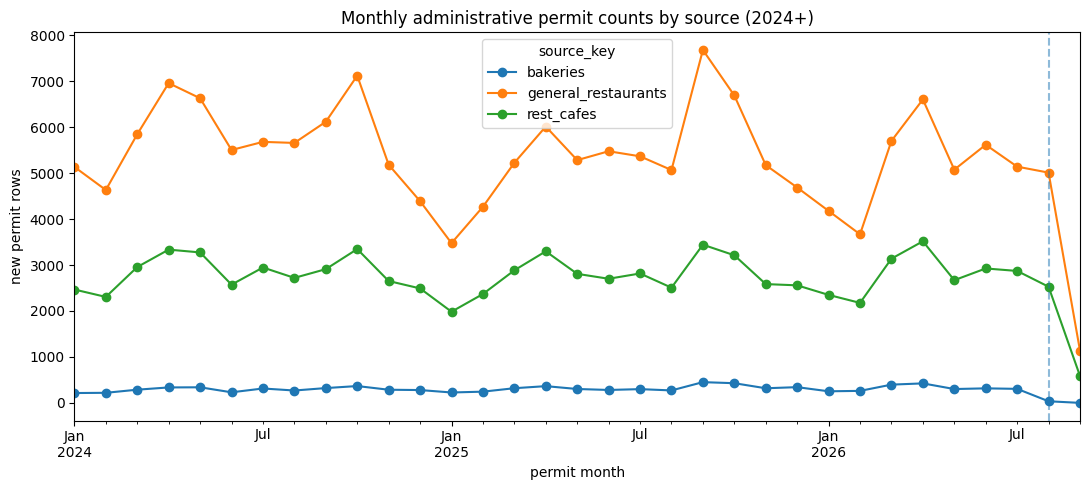

In [4]:
recent_plot = recent.pivot(index='permit_month', columns='source_key', values='permit_count').fillna(0)
ax = recent_plot.plot(figsize=(11, 5), marker='o', title='Monthly administrative permit counts by source (2024+)')
ax.axvline(pd.Timestamp('2026-08-01'), linestyle='--', alpha=0.5)
ax.set_ylabel('new permit rows')
ax.set_xlabel('permit month')
plt.tight_layout()
plt.show()


The plot is also a **data-freshness control**, not just an EDA chart. The current snapshot shows an unusually sharp bakery drop in 2026-08 while all three sources have rows dated through 2026-09-04. Rather than silently treating that as a real market collapse, the model evaluation stops at **2026-06 targets**.


## 3. Stable modeling window and seasonality

In [5]:
stable = monthly_raw[(monthly_raw['permit_month'] >= '2018-01-01') & (monthly_raw['permit_month'] <= '2026-06-01')].copy()

yearly = stable.groupby(stable['permit_month'].dt.year)['permit_count'].sum()
print(yearly.to_string())

seasonality = (
    stable[stable['permit_year'].between(2018, 2025)]
    .groupby(['permit_month_num', 'source_key'], as_index=False)['permit_count']
    .mean()
)
seasonality_pivot = seasonality.pivot(index='permit_month_num', columns='source_key', values='permit_count')
seasonality_pivot


permit_month
2018     99715
2019    108902
2020    102799
2021    107559
2022    104377
2023    111354
2024    106288
2025    101414
2026     49569


source_key,bakeries,general_restaurants,rest_cafes
permit_month_num,,,
1,2.110215,20.441939,11.367118
2,2.240055,20.059417,11.478992
3,2.513707,25.923503,14.112327
4,2.534183,27.960352,15.189359
5,2.483041,26.507726,14.573978
6,2.275362,26.165929,13.996508
7,2.399009,25.615427,13.955696
8,2.364544,24.703724,13.446895
9,2.447336,26.030387,13.306275


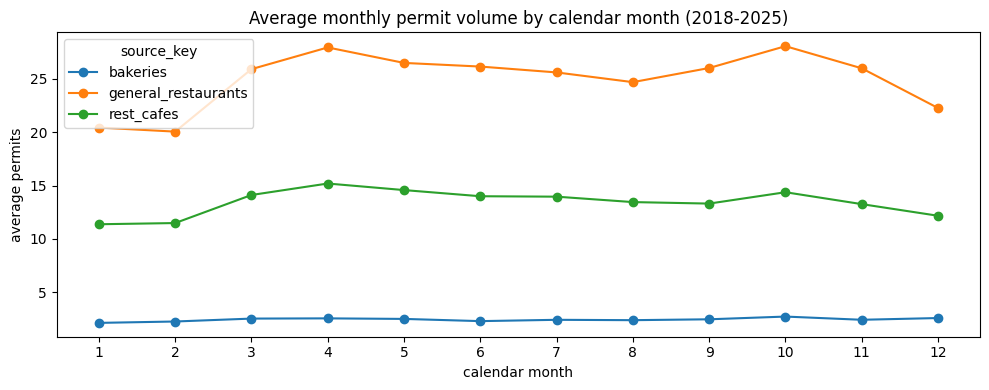

In [6]:
ax = seasonality_pivot.plot(figsize=(10, 4), marker='o', title='Average monthly permit volume by calendar month (2018-2025)')
ax.set_xlabel('calendar month')
ax.set_ylabel('average permits')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()


## 4. Build a complete authority × category × month panel

In [7]:
authorities = sorted(stable['authority_code'].unique())
sources = sorted(stable['source_key'].unique())
months = pd.date_range('2018-01-01', '2026-06-01', freq='MS')

observed = stable.set_index(['permit_month', 'authority_code', 'source_key'])['permit_count']
full_index = pd.MultiIndex.from_product(
    [months, authorities, sources],
    names=['permit_month', 'authority_code', 'source_key'],
)
panel = (
    observed.reindex(full_index, fill_value=0)
            .rename('permit_count')
            .reset_index()
            .sort_values(['authority_code', 'source_key', 'permit_month'])
            .reset_index(drop=True)
)

print(f'Authorities: {len(authorities):,}')
print(f'Categories:  {len(sources):,}')
print(f'Market series: {len(authorities) * len(sources):,}')
print(f'Panel rows: {len(panel):,}')


Authorities: 230
Categories:  3
Market series: 690
Panel rows: 70,380


## 5. Leakage-safe feature engineering

In [8]:
keys = ['authority_code', 'source_key']
grouped = panel.groupby(keys)['permit_count']

LAGS = [1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15]
for lag in LAGS:
    panel[f'lag_{lag}'] = grouped.shift(lag)

for window in (3, 6, 12):
    panel[f'roll_sum_{window}'] = grouped.transform(
        lambda s: s.shift(1).rolling(window, min_periods=window).sum()
    )

# Direct 3-month-ahead cumulative target: t+1 + t+2 + t+3.
panel['target_3m'] = grouped.shift(-1) + grouped.shift(-2) + grouped.shift(-3)

# Same three calendar months one year earlier.
panel['seasonal_naive_3m'] = panel['lag_9'] + panel['lag_10'] + panel['lag_11']
panel['momentum_3v3'] = (
    panel['lag_1'] + panel['lag_2'] + panel['lag_3']
    - panel['lag_4'] - panel['lag_5'] - panel['lag_6']
)
panel['yoy_last_month'] = panel['lag_1'] - panel['lag_13']

forecast_start = panel['permit_month'] + pd.offsets.MonthBegin(1)
panel['month_sin'] = np.sin(2 * np.pi * forecast_start.dt.month / 12)
panel['month_cos'] = np.cos(2 * np.pi * forecast_start.dt.month / 12)

NUMERIC_FEATURES = [f'lag_{lag}' for lag in LAGS] + [
    'roll_sum_3', 'roll_sum_6', 'roll_sum_12',
    'momentum_3v3', 'yoy_last_month', 'month_sin', 'month_cos',
]
CATEGORICAL_FEATURES = ['authority_code', 'source_key']
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

model_panel = panel.dropna(subset=NUMERIC_FEATURES + ['seasonal_naive_3m']).copy()
print(model_panel[['permit_month', 'target_3m', 'seasonal_naive_3m']].describe())


                        permit_month     target_3m  seasonal_naive_3m
count                          60030  57960.000000       60030.000000
mean   2022-10-31 13:14:28.965517056     38.245618          38.284941
min              2019-04-01 00:00:00      0.000000           0.000000
25%              2021-01-01 00:00:00      3.000000           3.000000
50%              2022-11-01 00:00:00     14.000000          14.000000
75%              2024-09-01 00:00:00     51.000000          52.000000
max              2026-06-01 00:00:00    500.000000         500.000000
std                              NaN     57.012065          57.123022


### Why the feature set is intentionally narrow

The current snapshot contains status, closure, names, addresses, and current coordinates, but using today's values while pretending to forecast 2024 or 2025 would leak future information. The backtest therefore uses **only historical permit-count features and stable identifiers**.

That makes this a valid demand-forecasting experiment from the current snapshot, not a disguised use of future state.


## 6. Metrics that connect to business decisions

In [9]:
def business_metrics(y_true, y_pred, top_share=0.10):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    k = max(1, int(np.ceil(len(y) * top_share)))
    top_idx = np.argsort(-p)[:k]
    actual_total = max(y.sum(), 1.0)
    capture = y[top_idx].sum() / actual_total
    return {
        'mae': mean_absolute_error(y, p),
        'rmse': float(np.sqrt(mean_squared_error(y, p))),
        'wape': float(np.abs(y - p).sum() / actual_total),
        'top10_capture': float(capture),
        'top10_lift_vs_random': float(capture / top_share),
    }

def make_xgb(objective, **extra):
    prep = ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)],
        remainder='passthrough',
    )
    model = XGBRegressor(
        objective=objective,
        n_estimators=180,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.90,
        colsample_bytree=0.90,
        min_child_weight=5,
        reg_lambda=2.0,
        n_jobs=4,
        tree_method='hist',
        random_state=42,
        **extra,
    )
    return Pipeline([('prep', prep), ('model', model)])


## 7. Quarterly walk-forward validation

In [10]:
CUTOFFS = pd.to_datetime([
    '2024-03-01', '2024-06-01', '2024-09-01', '2024-12-01',
    '2025-03-01', '2025-06-01', '2025-09-01', '2025-12-01',
    '2026-03-01',
])

MODEL_SPECS = {
    'xgb_poisson': ('count:poisson', {}),
    'xgb_square': ('reg:squarederror', {}),
    'xgb_tweedie': ('reg:tweedie', {'tweedie_variance_power': 1.3}),
}

fold_metrics = []
fold_predictions = []

for cutoff in CUTOFFS:
    # At cutoff t, a historical training row is allowed only if its t+1:t+3
    # target has already finished by the cutoff.
    train = model_panel[
        (model_panel['permit_month'] <= cutoff - pd.DateOffset(months=3))
        & model_panel['target_3m'].notna()
    ]
    test = model_panel[model_panel['permit_month'] == cutoff].copy()

    predictions = {'seasonal_naive': test['seasonal_naive_3m'].to_numpy(float)}
    for model_name, (objective, extra) in MODEL_SPECS.items():
        fitted = make_xgb(objective, **extra)
        fitted.fit(train[FEATURES], train['target_3m'])
        predictions[model_name] = fitted.predict(test[FEATURES])

    predictions['seasonal_ml_blend'] = (
        0.70 * np.clip(predictions['xgb_poisson'], 0, None)
        + 0.30 * np.clip(predictions['seasonal_naive'], 0, None)
    )

    for model_name, pred in predictions.items():
        metrics = business_metrics(test['target_3m'], pred)
        fold_metrics.append({'cutoff': cutoff, 'model': model_name, **metrics})

    test_out = test[['permit_month', 'authority_code', 'source_key', 'target_3m']].copy()
    for model_name, pred in predictions.items():
        test_out[model_name] = np.clip(pred, 0, None)
    fold_predictions.append(test_out)

metrics_df = pd.DataFrame(fold_metrics)
summary = metrics_df.groupby('model')[['mae', 'rmse', 'wape', 'top10_capture', 'top10_lift_vs_random']].mean()
summary.sort_values('wape')


,mae,rmse,wape,top10_capture,top10_lift_vs_random
model,,,,,
seasonal_ml_blend,6.985935,11.817338,0.187175,0.439379,4.393788
xgb_tweedie,7.066290,12.111154,0.189559,0.439273,4.392726
xgb_square,7.100270,12.166977,0.190424,0.439517,4.395167
xgb_poisson,7.130604,12.121233,0.191343,0.439459,4.394590
seasonal_naive,7.907568,13.515735,0.211279,0.438596,4.385957


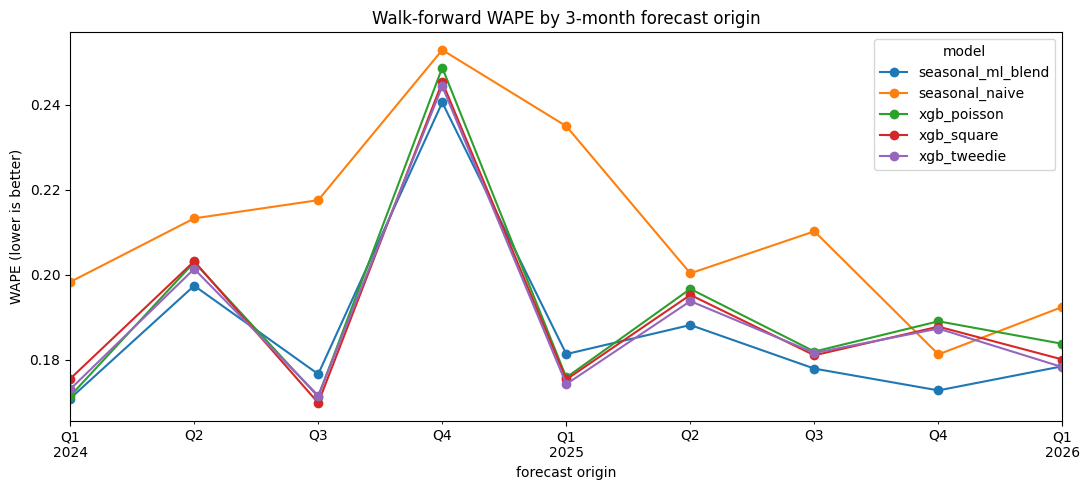

In [11]:
wape_pivot = metrics_df.pivot(index='cutoff', columns='model', values='wape')
ax = wape_pivot.plot(figsize=(11, 5), marker='o', title='Walk-forward WAPE by 3-month forecast origin')
ax.set_ylabel('WAPE (lower is better)')
ax.set_xlabel('forecast origin')
plt.tight_layout()
plt.show()


## 8. How much does ML improve on the seasonal baseline?

In [12]:
baseline_wape = summary.loc['seasonal_naive', 'wape']
best_model_name = summary['wape'].idxmin()
best_wape = summary.loc[best_model_name, 'wape']
relative_improvement = (baseline_wape - best_wape) / baseline_wape

print(f'Best average model: {best_model_name}')
print(f'Seasonal naive average WAPE: {baseline_wape:.2%}')
print(f'Best model average WAPE:     {best_wape:.2%}')
print(f'Relative WAPE improvement:   {relative_improvement:.1%}')
print(f'Top-10% market capture:      {summary.loc[best_model_name, "top10_capture"]:.1%}')
print(f'Lift vs random 10% targeting:{summary.loc[best_model_name, "top10_lift_vs_random"]:.2f}x')


Best average model: seasonal_ml_blend
Seasonal naive average WAPE: 21.13%
Best model average WAPE:     18.72%
Relative WAPE improvement:   11.4%
Top-10% market capture:      43.9%
Lift vs random 10% targeting:4.39x


**Business interpretation:** the forecasting improvement and the targeting concentration are separate facts. In this dataset, the top 10% of authority-category markets capture roughly four times the permit volume expected from random 10% targeting. The ML model primarily improves **volume calibration** over seasonal naive; it does not magically create all of that concentration.


## 9. Final out-of-time example: forecast 2026 Q2 from March 2026

In [13]:
FINAL_CUTOFF = pd.Timestamp('2026-03-01')
final_train = model_panel[
    (model_panel['permit_month'] <= FINAL_CUTOFF - pd.DateOffset(months=3))
    & model_panel['target_3m'].notna()
]
final_test = model_panel[model_panel['permit_month'] == FINAL_CUTOFF].copy()

final_tweedie = make_xgb('reg:tweedie', tweedie_variance_power=1.3)
final_tweedie.fit(final_train[FEATURES], final_train['target_3m'])
final_test['xgb_tweedie'] = np.clip(final_tweedie.predict(final_test[FEATURES]), 0, None)
final_test['seasonal_ml_blend'] = (
    0.70 * np.clip(
        make_xgb('count:poisson').fit(final_train[FEATURES], final_train['target_3m']).predict(final_test[FEATURES]),
        0, None,
    )
    + 0.30 * final_test['seasonal_naive_3m']
)

for name in ['xgb_tweedie', 'seasonal_ml_blend', 'seasonal_naive_3m']:
    print(name, business_metrics(final_test['target_3m'], final_test[name]))


xgb_tweedie {'mae': 7.0934200821363405, 'rmse': 12.393562156046494, 'wape': 0.1783240374785614, 'top10_capture': 0.43359930046999673, 'top10_lift_vs_random': 4.335993004699967}
seasonal_ml_blend {'mae': 7.101469875876455, 'rmse': 12.193757786012071, 'wape': 0.17852640413723736, 'top10_capture': 0.432652020257223, 'top10_lift_vs_random': 4.32652020257223}
seasonal_naive_3m {'mae': 7.656521739130435, 'rmse': 13.017435353724856, 'wape': 0.19248005246475025, 'top10_capture': 0.4339636390133712, 'top10_lift_vs_random': 4.339636390133712}


## 10. Opportunity ranking for a sales / expansion team

In [14]:
# Use the blend for a stable operating score, then rank within each category.
final_test['opportunity_score'] = (
    final_test.groupby('source_key')['seasonal_ml_blend']
              .rank(method='average', pct=True)
              .mul(100)
)

top_markets = (
    final_test.sort_values(['source_key', 'opportunity_score'], ascending=[True, False])
              .groupby('source_key', as_index=False)
              .head(10)
              [['source_key', 'authority_code', 'opportunity_score', 'seasonal_ml_blend', 'target_3m']]
              .rename(columns={
                  'seasonal_ml_blend': 'predicted_next_3m_permits',
                  'target_3m': 'actual_next_3m_permits',
              })
)
top_markets


,source_key,authority_code,opportunity_score,predicted_next_3m_permits,actual_next_3m_permits
6830,bakeries,3220000,100.000000,42.627632,35.0
7136,bakeries,3230000,99.565217,36.175552,43.0
12644,bakeries,3410000,99.130435,25.521315,11.0
21518,bakeries,3740000,98.695652,25.053912,34.0
61298,bakeries,5710000,98.260870,24.789334,23.0
24272,bakeries,3940000,97.826087,23.785326,18.0
37736,bakeries,4490000,97.391304,22.698758,15.0
19376,bakeries,3670000,96.956522,21.813148,17.0
12950,bakeries,3420000,96.521739,21.166237,6.0
27026,bakeries,4050000,96.086957,20.289473,13.0


## 11. Add a broad address-derived region label for readability

In [15]:
address_raw = pq.read_table(PARQUET, columns=['authority_code', 'road_address', 'lot_address'])
road = address_raw['road_address']
lot = address_raw['lot_address']
use_lot = pc.or_(pc.is_null(road), pc.equal(pc.fill_null(road, ''), ''))
address = pc.if_else(use_lot, lot, road)
region_proxy = pc.list_element(pc.split_pattern(address, pattern=' '), 0)

region_table = pa.table({
    'authority_code': pc.cast(address_raw['authority_code'], pa.string()),
    'region_proxy': region_proxy,
})
region_counts = (
    region_table.group_by(['authority_code', 'region_proxy'])
                .aggregate([('authority_code', 'count')])
                .to_pandas()
                .rename(columns={'authority_code_count': 'records'})
                .dropna(subset=['authority_code', 'region_proxy'])
)
region_map = (
    region_counts.sort_values(['authority_code', 'records'], ascending=[True, False])
                 .drop_duplicates('authority_code')
                 [['authority_code', 'region_proxy']]
)

top_markets = top_markets.merge(region_map, on='authority_code', how='left')
top_markets[['region_proxy', 'source_key', 'authority_code', 'opportunity_score', 'predicted_next_3m_permits', 'actual_next_3m_permits']]


,region_proxy,source_key,authority_code,opportunity_score,predicted_next_3m_permits,actual_next_3m_permits
0,서울특별시,bakeries,3220000,100.000000,42.627632,35.0
1,서울특별시,bakeries,3230000,99.565217,36.175552,43.0
2,대구광역시,bakeries,3410000,99.130435,25.521315,11.0
3,경기도,bakeries,3740000,98.695652,25.053912,34.0
4,충청북도,bakeries,5710000,98.260870,24.789334,23.0
5,경기도,bakeries,3940000,97.826087,23.785326,18.0
6,충청남도,bakeries,4490000,97.391304,22.698758,15.0
7,대전광역시,bakeries,3670000,96.956522,21.813148,17.0
8,대구광역시,bakeries,3420000,96.521739,21.166237,6.0
9,경기도,bakeries,4050000,96.086957,20.289473,13.0


`region_proxy` is only the first address token chosen by modal frequency within an `authority_code`. It is for readable nationwide context, **not** an authoritative administrative boundary join.


## 12. Empirical uncertainty bands from walk-forward residuals

In [16]:
all_fold_predictions = pd.concat(fold_predictions, ignore_index=True)
all_fold_predictions['blend_abs_error'] = np.abs(
    all_fold_predictions['target_3m'] - all_fold_predictions['seasonal_ml_blend']
)

# Source-specific 90th-percentile absolute backtest residual: a simple
# distribution-free empirical uncertainty band, not a guarantee of coverage.
q90_by_source = all_fold_predictions.groupby('source_key')['blend_abs_error'].quantile(0.90)
final_test['q90_abs_error'] = final_test['source_key'].map(q90_by_source)
final_test['forecast_lower_90'] = np.clip(final_test['seasonal_ml_blend'] - final_test['q90_abs_error'], 0, None)
final_test['forecast_upper_90'] = final_test['seasonal_ml_blend'] + final_test['q90_abs_error']

coverage = (
    (final_test['target_3m'] >= final_test['forecast_lower_90'])
    & (final_test['target_3m'] <= final_test['forecast_upper_90'])
).mean()
print(f'Empirical final-holdout interval coverage: {coverage:.1%}')
final_test[['source_key', 'authority_code', 'seasonal_ml_blend', 'forecast_lower_90', 'forecast_upper_90', 'target_3m']].head()


Empirical final-holdout interval coverage: 88.8%


,source_key,authority_code,seasonal_ml_blend,forecast_lower_90,forecast_upper_90,target_3m
98,bakeries,3000000,5.226375,0.946152,9.506599,4.0
200,general_restaurants,3000000,91.527939,63.983016,119.072862,126.0
302,rest_cafes,3000000,39.413250,23.725791,55.100710,40.0
404,bakeries,3010000,15.290183,11.009960,19.570407,20.0
506,general_restaurants,3010000,154.264355,126.719432,181.809279,272.0


## 13. Explainability: what drives the Tweedie tree model?

In [17]:
try:
    import shap

    prep = final_tweedie.named_steps['prep']
    booster = final_tweedie.named_steps['model']
    sample = final_test[FEATURES].sample(min(1200, len(final_test)), random_state=42)
    transformed = prep.transform(sample)
    names = prep.get_feature_names_out()
    explainer = shap.TreeExplainer(booster)
    values = explainer(transformed)
    importance = pd.DataFrame({
        'feature': names,
        'mean_abs_shap': np.abs(values.values).mean(axis=0),
    }).sort_values('mean_abs_shap', ascending=False)
    display(importance.head(20))
except Exception as exc:
    print('SHAP could not be rendered in this runtime; falling back to model feature importance.')
    prep = final_tweedie.named_steps['prep']
    booster = final_tweedie.named_steps['model']
    importance = pd.DataFrame({
        'feature': prep.get_feature_names_out(),
        'importance': booster.feature_importances_,
    }).sort_values('importance', ascending=False)
    display(importance.head(20))
    print(type(exc).__name__, str(exc)[:200])


,feature,mean_abs_shap
248,remainder__roll_sum_12,1.079235
247,remainder__roll_sum_6,0.240989
240,remainder__lag_10,0.086742
239,remainder__lag_9,0.063829
241,remainder__lag_11,0.057901
252,remainder__month_cos,0.050452
245,remainder__lag_15,0.024432
243,remainder__lag_13,0.020771
244,remainder__lag_14,0.019371
251,remainder__month_sin,0.013728


## 14. Where this becomes a real product

### MVP: Korea F&B Permit Demand Intelligence

Deliver the model as a monthly table/API:

`forecast_origin, authority_code, category, predicted_3m_permits, opportunity_score, uncertainty_low, uncertainty_high`

Potential buyers/users:

- **POS / payments:** allocate field sales capacity toward markets with the highest expected new-permit volume;
- **food suppliers / equipment vendors:** pre-position sales inventory and prospecting effort;
- **franchise teams:** use the score as a first-pass market-growth screen before rent, population, footfall, and sales data are added;
- **commercial real estate:** monitor where F&B permitting activity is strengthening.

### What the model does *not* claim

- It predicts **administrative permit counts**, not revenue or physical store openings.
- It does not infer historical monthly active-store populations from today's snapshot.
- It does not use `closure_date` as an irreversible event.
- It does not treat `management_number` as an official business primary key.
- It should be refreshed only after source-freshness checks pass; the 2026-08 bakery anomaly is an example of why this matters.

### Highest-value next step

Once true monthly snapshots accumulate, add **survival / state-transition targets** and external population, rent, footfall, tourism, or card-spend data. That would turn this demand signal into a richer store-expansion decision system.
